In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from IQAEBinom_OnlyFinalRound import IQAEBinom_OnlyFinalRound

In [2]:
pTrue = 0.2
nGrover = 100
nShot = 100

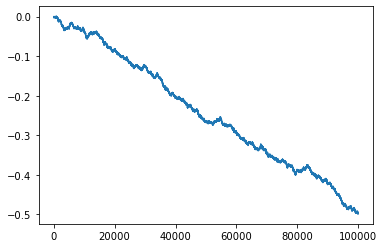

In [3]:
nEstim = 100000
estims = np.array([])
p1ObsFinals = np.array([])
for _ in range(nEstim):
    estim, p1ObsFinal = IQAEBinom_OnlyFinalRound(pTrue, nGrover, nShot)
    estims = np.append(estims, estim)
    p1ObsFinals = np.append(p1ObsFinals, p1ObsFinal)

errors = estims - pTrue
ax = plt.gca()
plt.plot(errors.cumsum())
plt.show()

In [4]:
# bias見積り
np.mean(errors)

-4.963638683682018e-06

In [18]:
# bias見積りの統計誤差
np.sqrt(np.var(errors) / nEstim)

6.340263513209247e-07

In [5]:
from BiasCorrection import BiasCordeiroKlein, BiasTaylorExpTo2nd, BiasTaylorExpTo3rd

In [6]:
# Cordeiro-Kleinのbias理論式　→　合わず...
BiasCordeiroKlein(pTrue, nGrover, nShot)

-2.384697028700929e-05

テイラー近似によるバイアス理論式は2シグマ以内で合ってる

In [7]:
BiasTaylorExpTo2nd(pTrue, nGrover, nShot)

-5.90605088095259e-06

In [8]:
BiasTaylorExpTo3rd(pTrue, nGrover, nShot)

-5.826542542985285e-06